---



---

# **JOBSHEET 5 - MENGUKUR KEMIRIPAN CITRA**

---



---

NAMA : Muhammad Eka Sobirin

NIM : 3.34.23.2.14

Mata Kuliah : Pengolahan Citra

Dosen Pengampu : Ir. Prayitno, S.ST., M.T., Ph.D.



---



---


##**PRAKTIKUM 1**
###Menghitung Jarak Berbasis Piksel (Euclidean & Manhattan)

Jarak Euclidean Patch 1 dan Patch 2 : 24.7650
Jarak Euclidean Patch 1 dan Patch 3 : 5.0000
Jarak Manhattan Patch 1 dan Patch 2 : 936.4392
Jarak Manhattan Patch 1 dan Patch 3 : 250.0000


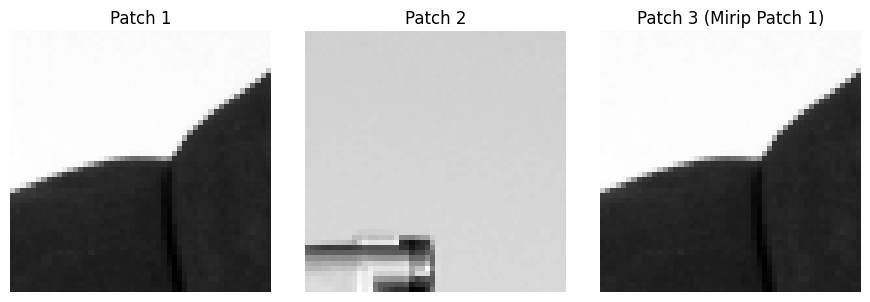

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data, img_as_float
from scipy.spatial import distance


# =========================================================
# 1. Mengambil citra dan membuat beberapa patch
# =========================================================

# Mengambil citra grayscale bawaan dari skimage
image = img_as_float(data.camera())

# Patch pertama
patch1 = image[100:150, 100:150]

# Patch kedua dari lokasi berbeda
patch2 = image[100:150, 300:350]

# Patch ketiga dibuat dari patch1 dengan sedikit perubahan intensitas
patch3 = patch1 + 0.1

# Membatasi nilai piksel agar tetap pada rentang [0, 1]
patch3 = np.clip(patch3, 0, 1)


# =========================================================
# 2. Mengubah patch menjadi vektor 1 dimensi
# =========================================================

vec1 = patch1.flatten()
vec2 = patch2.flatten()
vec3 = patch3.flatten()


# =========================================================
# 3. Menghitung jarak Euclidean (L2)
# =========================================================

dist_l2_12 = distance.euclidean(vec1, vec2)
dist_l2_13 = distance.euclidean(vec1, vec3)


# =========================================================
# 4. Menghitung jarak Manhattan (L1)
# =========================================================

dist_l1_12 = distance.cityblock(vec1, vec2)
dist_l1_13 = distance.cityblock(vec1, vec3)


# =========================================================
# 5. Menampilkan hasil perhitungan
# =========================================================

print(f"Jarak Euclidean Patch 1 dan Patch 2 : {dist_l2_12:.4f}")
print(f"Jarak Euclidean Patch 1 dan Patch 3 : {dist_l2_13:.4f}")

print(f"Jarak Manhattan Patch 1 dan Patch 2 : {dist_l1_12:.4f}")
print(f"Jarak Manhattan Patch 1 dan Patch 3 : {dist_l1_13:.4f}")


# =========================================================
# 6. Visualisasi patch citra
# =========================================================

fig, axes = plt.subplots(1, 3, figsize=(9, 3))

# Patch 1
axes[0].imshow(patch1, cmap='gray')
axes[0].set_title('Patch 1')
axes[0].axis('off')

# Patch 2
axes[1].imshow(patch2, cmap='gray')
axes[1].set_title('Patch 2')
axes[1].axis('off')

# Patch 3
axes[2].imshow(patch3, cmap='gray')
axes[2].set_title('Patch 3 (Mirip Patch 1)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

##**PRAKTIKUM 2**
###Menghitung Cosine Similarity antara Histogram Warna

Cosine Similarity Image 1 dan Image 2 : 0.8156
Cosine Similarity Image 1 dan Image 3 : 1.0000
Cosine Similarity Image 1 dan Image 4 : 1.0000


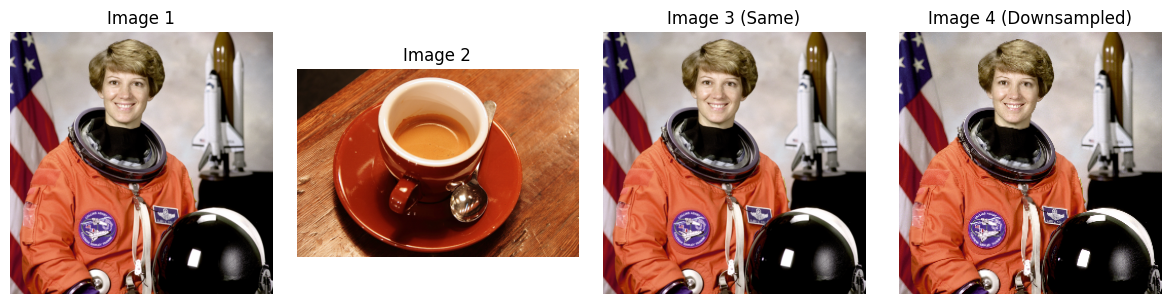

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data, img_as_ubyte
from scipy.spatial import distance


# =========================================================
# Fungsi untuk menghitung histogram RGB gabungan
# =========================================================

def calculate_rgb_histogram(image, bins=16):

    # Konversi citra ke uint8
    img_uint8 = img_as_ubyte(image)

    # Histogram kanal merah
    hist_r, _ = np.histogram(
        img_uint8[:, :, 0].ravel(),
        bins=bins,
        range=(0, 256)
    )

    # Histogram kanal hijau
    hist_g, _ = np.histogram(
        img_uint8[:, :, 1].ravel(),
        bins=bins,
        range=(0, 256)
    )

    # Histogram kanal biru
    hist_b, _ = np.histogram(
        img_uint8[:, :, 2].ravel(),
        bins=bins,
        range=(0, 256)
    )

    # Menggabungkan histogram RGB
    hist_combined = np.concatenate((hist_r, hist_g, hist_b))

    # Normalisasi histogram
    hist_combined = hist_combined.astype(float) / np.sum(hist_combined)

    return hist_combined


# =========================================================
# 1. Memuat citra berwarna
# =========================================================

try:
    image1 = data.astronaut()
    image2 = data.coffee()          # Citra berbeda
    image3 = data.astronaut()       # Citra sama
    image4 = image1[::2, ::2, :]    # Versi downsampled

except Exception as e:
    print(f"Gagal memuat data skimage: {e}")

    # Membuat citra dummy
    image1 = np.random.rand(100, 100, 3)
    image2 = np.random.rand(100, 100, 3) * 0.5
    image3 = image1.copy()
    image4 = image1[::2, ::2, :]


# =========================================================
# 2. Menghitung histogram setiap citra
# =========================================================

hist1 = calculate_rgb_histogram(image1)
hist2 = calculate_rgb_histogram(image2)
hist3 = calculate_rgb_histogram(image3)
hist4 = calculate_rgb_histogram(image4)


# =========================================================
# 3. Menghitung Cosine Similarity
# =========================================================

sim_12 = 1 - distance.cosine(hist1, hist2)
sim_13 = 1 - distance.cosine(hist1, hist3)
sim_14 = 1 - distance.cosine(hist1, hist4)


# =========================================================
# 4. Menampilkan hasil
# =========================================================

print(f"Cosine Similarity Image 1 dan Image 2 : {sim_12:.4f}")
print(f"Cosine Similarity Image 1 dan Image 3 : {sim_13:.4f}")
print(f"Cosine Similarity Image 1 dan Image 4 : {sim_14:.4f}")


# =========================================================
# 5. Visualisasi citra
# =========================================================

fig, axes = plt.subplots(1, 4, figsize=(12, 3))

axes[0].imshow(image1)
axes[0].set_title('Image 1')
axes[0].axis('off')

axes[1].imshow(image2)
axes[1].set_title('Image 2')
axes[1].axis('off')

axes[2].imshow(image3)
axes[2].set_title('Image 3 (Same)')
axes[2].axis('off')

axes[3].imshow(image4)
axes[3].set_title('Image 4 (Downsampled)')
axes[3].axis('off')

plt.tight_layout()
plt.show()

##**PRAKTIKUM 3**
###Menghitung Structural Similarity Index (SSIM)

SSIM (Reference vs Same)     : 1.0000
SSIM (Reference vs Noisy)    : 0.2964
SSIM (Reference vs Contrast) : 0.9651
SSIM (Reference vs Blurred)  : 0.8027


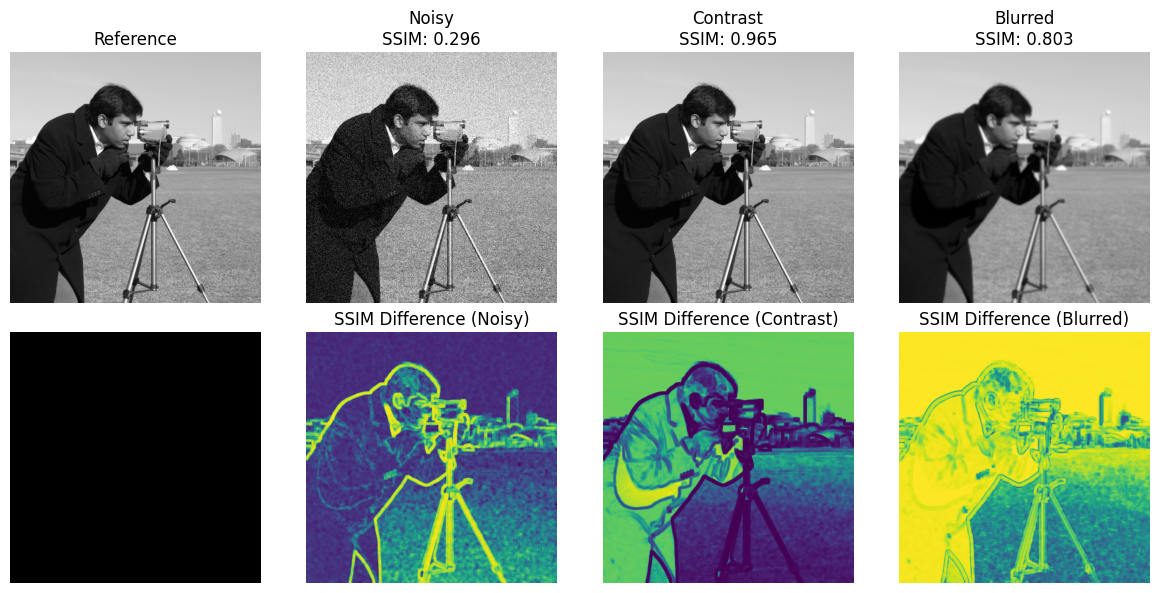

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data, img_as_float
from skimage.metrics import structural_similarity as ssim
from skimage.util import random_noise
from skimage.filters import gaussian


# =========================================================
# 1. Memuat citra referensi
# =========================================================

image_ref = img_as_float(data.camera())


# =========================================================
# 2. Membuat beberapa versi citra terdistorsi
# =========================================================

# Citra sama persis
image_same = image_ref.copy()

# Citra dengan noise Gaussian
image_noisy = random_noise(
    image_ref,
    mode='gaussian',
    var=0.01
)

# Citra dengan perubahan kontras
image_contrast = np.clip(image_ref * 0.8, 0, 1)

# Citra blur
image_blurred = gaussian(
    image_ref,
    sigma=1.5,
    channel_axis=None
)


# =========================================================
# 3. Menghitung SSIM
# =========================================================

# Menghitung rentang data
data_range = image_ref.max() - image_ref.min()

# SSIM citra sama
ssim_same, _ = ssim(
    image_ref,
    image_same,
    data_range=data_range,
    full=True
)

# SSIM citra noisy
ssim_noisy, diff_noisy = ssim(
    image_ref,
    image_noisy,
    data_range=data_range,
    full=True
)

# SSIM citra kontras
ssim_contrast, diff_contrast = ssim(
    image_ref,
    image_contrast,
    data_range=data_range,
    full=True
)

# SSIM citra blur
ssim_blurred, diff_blurred = ssim(
    image_ref,
    image_blurred,
    data_range=data_range,
    full=True
)


# =========================================================
# 4. Menampilkan hasil SSIM
# =========================================================

print(f"SSIM (Reference vs Same)     : {ssim_same:.4f}")
print(f"SSIM (Reference vs Noisy)    : {ssim_noisy:.4f}")
print(f"SSIM (Reference vs Contrast) : {ssim_contrast:.4f}")
print(f"SSIM (Reference vs Blurred)  : {ssim_blurred:.4f}")


# =========================================================
# 5. Visualisasi hasil
# =========================================================

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
ax = axes.ravel()

# Baris pertama
ax[0].imshow(image_ref, cmap='gray')
ax[0].set_title('Reference')
ax[0].axis('off')

ax[1].imshow(image_noisy, cmap='gray')
ax[1].set_title(f'Noisy\nSSIM: {ssim_noisy:.3f}')
ax[1].axis('off')

ax[2].imshow(image_contrast, cmap='gray')
ax[2].set_title(f'Contrast\nSSIM: {ssim_contrast:.3f}')
ax[2].axis('off')

ax[3].imshow(image_blurred, cmap='gray')
ax[3].set_title(f'Blurred\nSSIM: {ssim_blurred:.3f}')
ax[3].axis('off')


# =========================================================
# 6. Menampilkan peta perbedaan SSIM
# =========================================================

ax[4].imshow(np.zeros_like(image_ref), cmap='gray')
ax[4].set_title('')
ax[4].axis('off')

ax[5].imshow(diff_noisy, cmap='viridis')
ax[5].set_title('SSIM Difference (Noisy)')
ax[5].axis('off')

ax[6].imshow(diff_contrast, cmap='viridis')
ax[6].set_title('SSIM Difference (Contrast)')
ax[6].axis('off')

ax[7].imshow(diff_blurred, cmap='viridis')
ax[7].set_title('SSIM Difference (Blurred)')
ax[7].axis('off')

plt.tight_layout()
plt.show()

##**PRAKTIKUM 4**
###Penerapan Template Matching

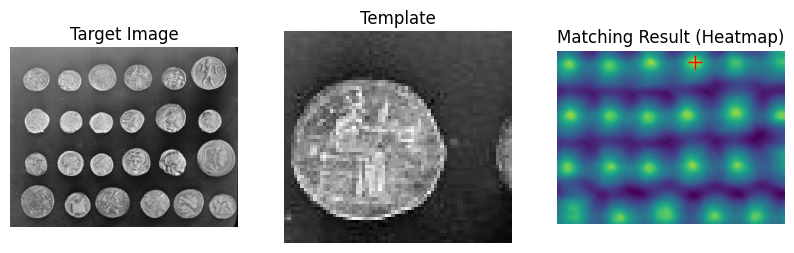

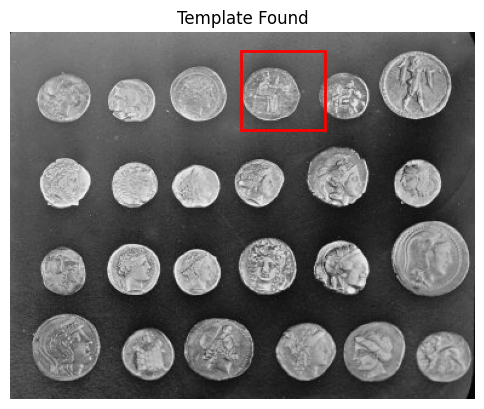

Template ditemukan pada koordinat (x, y): (190, 15)


In [5]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data
from skimage.feature import match_template


# =========================================================
# 1. Memuat citra target dan template
# =========================================================

# Mengambil citra koin
image = data.coins()

# Mengambil salah satu bagian koin sebagai template
template = image[15:80, 190:260]


# =========================================================
# 2. Melakukan template matching
# =========================================================

# Menggunakan metode Normalized Cross-Correlation
result = match_template(image, template)


# =========================================================
# 3. Menentukan lokasi dengan nilai kecocokan tertinggi
# =========================================================

# Mencari indeks dengan skor terbesar
ij = np.unravel_index(np.argmax(result), result.shape)

# Mengubah koordinat menjadi format (x, y)
x, y = ij[::-1]


# =========================================================
# 4. Visualisasi hasil template matching
# =========================================================

fig, ax = plt.subplots(1, 3, figsize=(10, 4))

# Menampilkan citra target
ax[0].imshow(image, cmap='gray')
ax[0].set_title('Target Image')
ax[0].set_axis_off()

# Menampilkan template
ax[1].imshow(template, cmap='gray')
ax[1].set_title('Template')
ax[1].set_axis_off()

# Menampilkan heatmap hasil matching
ax[2].imshow(result, cmap='viridis')
ax[2].set_title('Matching Result (Heatmap)')
ax[2].set_axis_off()

# Menandai lokasi terbaik pada heatmap
ax[2].plot(x, y, 'r+', markersize=10)


# =========================================================
# 5. Menampilkan lokasi template pada citra asli
# =========================================================

fig2, ax_main = plt.subplots(figsize=(6, 6))

ax_main.imshow(image, cmap='gray')
ax_main.set_title('Template Found')
ax_main.set_axis_off()

# Ukuran template
h, w = template.shape

# Membuat kotak penanda
rect = plt.Rectangle(
    (x, y),
    w,
    h,
    edgecolor='red',
    facecolor='none',
    lw=2
)

# Menambahkan kotak ke gambar
ax_main.add_patch(rect)

plt.show()


# =========================================================
# 6. Menampilkan koordinat hasil pencocokan
# =========================================================

print(f"Template ditemukan pada koordinat (x, y): ({x}, {y})")

##**PRAKTIKUM 5**
###Simulasi Content-Based Image Retrieval (CBIR) Sederhana

Memproses database citra...
- astronaut diproses.
- camera diproses.
- coffee diproses.
- coins diproses.
- chelsea diproses.

Hasil Retrieval:
Rank 1: chelsea (Distance: 0.000)
Rank 2: coins (Distance: 0.288)
Rank 3: coffee (Distance: 0.359)
Rank 4: astronaut (Distance: 0.461)
Rank 5: camera (Distance: 0.602)


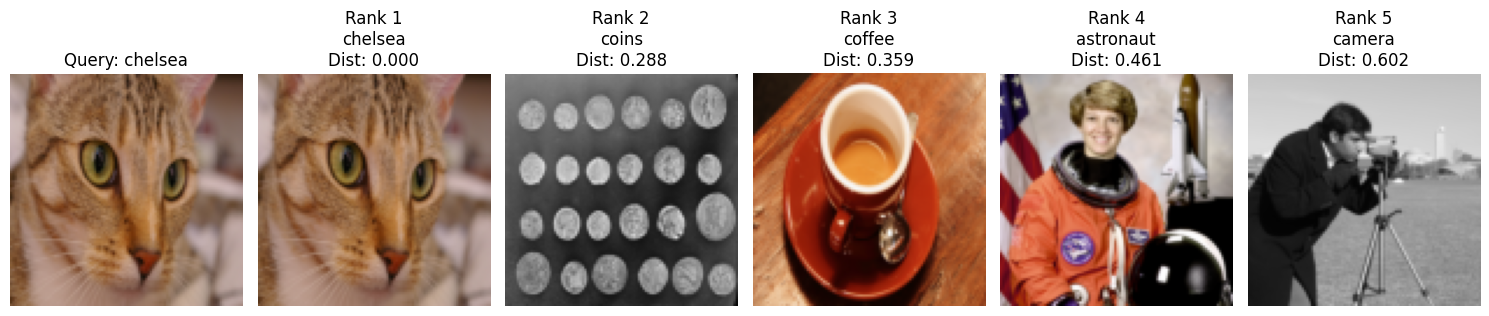

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import (
    data,
    color,
    transform,
    img_as_ubyte
)

from scipy.spatial import distance


# =========================================================
# Fungsi menghitung histogram RGB
# =========================================================

def calculate_rgb_histogram(image, bins=16):

    # Konversi citra float ke uint8
    if image.dtype == float:
        image = img_as_ubyte(image)

    # Histogram kanal merah
    hist_r, _ = np.histogram(
        image[:, :, 0].ravel(),
        bins=bins,
        range=(0, 256)
    )

    # Histogram kanal hijau
    hist_g, _ = np.histogram(
        image[:, :, 1].ravel(),
        bins=bins,
        range=(0, 256)
    )

    # Histogram kanal biru
    hist_b, _ = np.histogram(
        image[:, :, 2].ravel(),
        bins=bins,
        range=(0, 256)
    )

    # Menggabungkan histogram RGB
    hist_combined = np.concatenate((hist_r, hist_g, hist_b))

    # Normalisasi histogram
    hist_sum = np.sum(hist_combined)

    if hist_sum > 0:
        hist_combined = hist_combined.astype(float) / hist_sum
    else:
        hist_combined = hist_combined.astype(float)

    return hist_combined


# =========================================================
# 1. Menyiapkan database citra
# =========================================================

image_db_names = [
    "astronaut",
    "camera",
    "coffee",
    "coins",
    "chelsea"
]

database_images = []
database_hists = []

print("Memproses database citra...")

for name in image_db_names:

    try:
        # Memuat citra
        img = getattr(data, name)()

        # Jika grayscale, ubah menjadi RGB
        if img.ndim == 2:
            img = color.gray2rgb(img)

        # Resize citra
        img_resized = transform.resize(
            img,
            (100, 100),
            anti_aliasing=True
        )

        # Simpan citra dan histogram
        database_images.append(img_resized)
        database_hists.append(
            calculate_rgb_histogram(img_resized)
        )

        print(f"- {name} diproses.")

    except Exception as e:
        print(f"Error memproses {name}: {e}")


# =========================================================
# 2. Menentukan citra query
# =========================================================

query_image_name = "chelsea"

query_index = image_db_names.index(query_image_name)

query_image = database_images[query_index]
query_hist = database_hists[query_index]


# =========================================================
# 3. Menghitung jarak cosine
# =========================================================

distances = []

for hist in database_hists:

    dist = distance.cosine(query_hist, hist)
    distances.append(dist)


# =========================================================
# 4. Mengurutkan hasil berdasarkan jarak
# =========================================================

sorted_indices = np.argsort(distances)


# =========================================================
# 5. Menampilkan hasil retrieval
# =========================================================

num_results_to_show = len(database_images)

fig, axes = plt.subplots(
    1,
    num_results_to_show + 1,
    figsize=(15, 3)
)

# Menampilkan query
axes[0].imshow(query_image)
axes[0].set_title(f"Query: {query_image_name}")
axes[0].axis('off')

print("\nHasil Retrieval:")

# Menampilkan hasil ranking
for i, idx in enumerate(sorted_indices):

    img_rank = i + 1

    ax = axes[img_rank]

    ax.imshow(database_images[idx])

    ax.set_title(
        f"Rank {img_rank}\n"
        f"{image_db_names[idx]}\n"
        f"Dist: {distances[idx]:.3f}"
    )

    ax.axis('off')

    print(
        f"Rank {img_rank}: "
        f"{image_db_names[idx]} "
        f"(Distance: {distances[idx]:.3f})"
    )


# =========================================================
# 6. Menampilkan visualisasi
# =========================================================

plt.tight_layout()
plt.show()